# 2. Pre processamento

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
Path('../saidas').mkdir(exist_ok=True)

df = pd.read_csv('../data/base nova completa.csv', encoding='cp1252')

## Conversão de tipos

In [2]:
def para_numero(coluna):
    texto = coluna.astype(str).str.strip().str.replace(',', '')
    valor = pd.to_numeric(texto.str.rstrip('%'), errors='coerce')
    return valor / texto.str.endswith('%').map({True: 100, False: 1})

ausentes_antes = df.isna().sum().sum()

base = df.copy()
colunas_numericas = base.columns[2:]
base[colunas_numericas] = base[colunas_numericas].apply(para_numero)

print('ausentes antes:', ausentes_antes, '| depois:', base.isna().sum().sum())
base.dtypes.value_counts()

ausentes antes: 0 | depois: 0


float64    258
object       2
Name: count, dtype: int64

## Valores ausentes

In [3]:
ausentes = base.isna().sum()
ausentes[ausentes > 0]

Series([], dtype: int64)

In [4]:
base[colunas_numericas] = base.groupby('Tipo de unidade')[colunas_numericas].transform(lambda c: c.fillna(c.median()))

print('ausentes restantes:', base.isna().sum().sum())

ausentes restantes: 0


In [5]:
# linhas duplicadas: a planilha tem uma linha por unidade, então repetição seria lançamento em dobro
duplicadas = base.duplicated().sum()
base = base.drop_duplicates()
print('linhas duplicadas removidas:', duplicadas)

linhas duplicadas removidas: 0


## Colunas duplicadas

As quatro últimas colunas têm o mesmo nome de colunas anteriores (o pandas acrescenta `.1`). Elas são os **pontos** de cada indicador, ou seja, a nota multiplicada pelo peso. Dividindo uma pela outra aparece o peso de 20% do indicador 1:

In [6]:
eh_unidade = base['Tipo de unidade'] != 'DS'
razao = base.loc[eh_unidade, 'Desempenho consolidado — Indicador 1.1'] / base.loc[eh_unidade, 'Desempenho consolidado — Indicador 1']
razao.round(3).value_counts(dropna=False)

0.2    194
NaN      2
Name: count, dtype: int64

pela portaria o indicador 4 pesa 40% na unidade, então a nota é o ponto dividido por 0,4.

In [7]:
tabela = pd.DataFrame({
    'tipo': base['Tipo de unidade'],
    'familia': base['Tipo de unidade'].str.split().str[0],
    'distrito': base['Distrito Sanitário'],
    'ind1': base['Desempenho consolidado — Indicador 1'],
    'ind2': base['Desempenho consolidado — Indicador 2'],
    'ind3': base['Desempenho consolidado — Indicador 3'],
    'ind4': base['Desempenho consolidado — Indicador 4'] / 0.4,
    'geral': base['Desempenho geral'],
})

unidades = tabela[tabela['tipo'] != 'DS'].reset_index(drop=True)
unidades.shape

(196, 8)

## tratar os outliers

In [8]:
colunas = ['ind1', 'ind2', 'ind3', 'ind4', 'geral']

q1 = unidades[colunas].quantile(0.25)
q3 = unidades[colunas].quantile(0.75)
iqr = q3 - q1
fora_do_iqr = (unidades[colunas] < q1 - 1.5 * iqr) | (unidades[colunas] > q3 + 1.5 * iqr)
fora_do_iqr.sum()

ind1      2
ind2      5
ind3     25
ind4     35
geral    29
dtype: int64

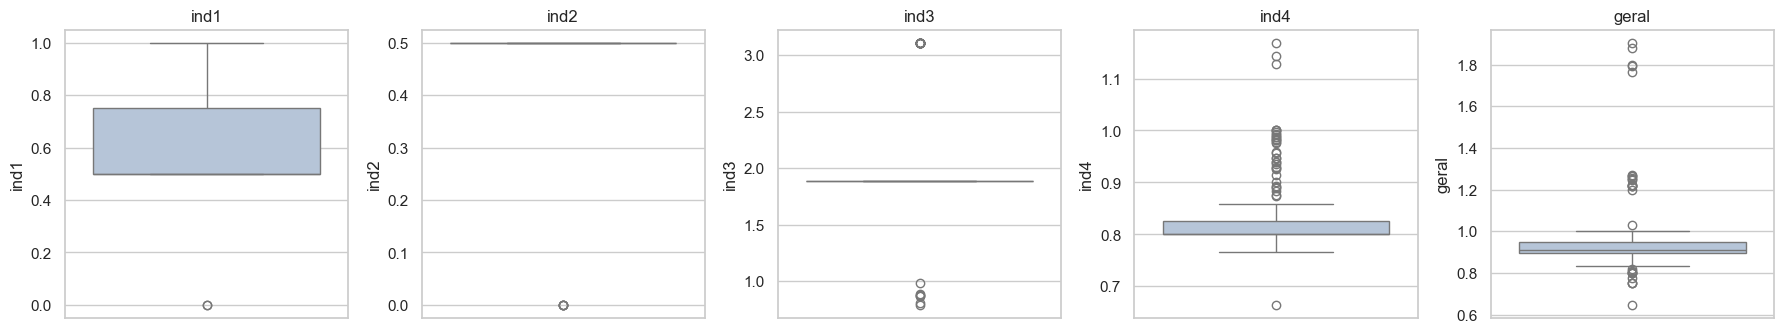

In [9]:
fig, eixos = plt.subplots(1, 5, figsize=(18, 3.5))
for eixo, coluna in zip(eixos, colunas):
    sns.boxplot(y=unidades[coluna], ax=eixo, color='lightsteelblue')
    eixo.set_title(coluna)
plt.tight_layout()
plt.show()

In [10]:
unidades[fora_do_iqr['geral']]['familia'].value_counts()

familia
MAC     18
SAE      3
NDI      3
USF      3
UCIS     1
UBT      1
Name: count, dtype: int64

In [11]:
esperado = 0.2 * unidades['ind1'] + 0.2 * unidades['ind2'] + 0.2 * unidades['ind3'] + 0.4 * unidades['ind4']
fora_da_regra = (unidades['geral'] - esperado).abs() > 0.01

print('linhas fora da regra:', fora_da_regra.sum())
unidades[fora_da_regra][['tipo', 'distrito', 'ind3', 'geral']].assign(esperado=esperado[fora_da_regra].round(4))

linhas fora da regra: 6


,tipo,distrito,ind3,geral,esperado
0,SAE,I,3.11,0.8161,1.3876
1,SAE,III,3.11,1.9049,1.3732
2,SAE,IV,3.11,1.8790,1.3291
3,NDI,III,3.11,1.7923,1.1816
4,NDI,VI,3.11,1.7989,1.1930
5,NDI,IV,3.11,1.7652,1.1356


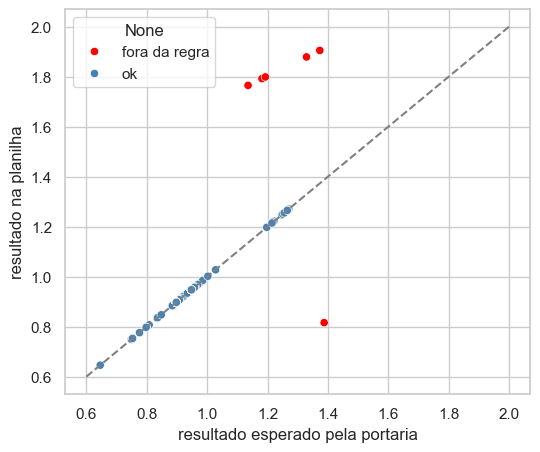

In [12]:
plt.figure(figsize=(6, 5))
sns.scatterplot(x=esperado, y=unidades['geral'], hue=fora_da_regra.map({True: 'fora da regra', False: 'ok'}), palette={'ok': 'steelblue', 'fora da regra': 'red'})
plt.plot([0.6, 2], [0.6, 2], color='gray', linestyle='--')
plt.xlabel('resultado esperado pela portaria')
plt.ylabel('resultado na planilha')
plt.show()

essas linhas são removidas, porque o resultado geral delas não segue a regra que os modelos vão aprender

In [13]:
unidades = unidades[~fora_da_regra].reset_index(drop=True)
unidades.to_csv('../saidas/unidades.csv', index=False)
print(unidades.shape)
unidades.head()

(190, 8)


,tipo,familia,distrito,ind1,ind2,ind3,ind4,geral
0,CAPS II ou III,CAPS,V,0.50,0.5,1.89,0.85000,0.9175
1,CAPS II ou III,CAPS,VI,0.75,0.5,1.89,0.87625,0.9779
2,CAPS II ou III,CAPS,IV,0.50,0.5,1.89,0.90150,0.9381
3,CAPS II ou III,CAPS,II,0.75,0.5,1.89,0.87375,0.9769
4,CAPS II ou III,CAPS,III,0.75,0.5,1.89,0.88975,0.9834


In [14]:
# feature engineering. as colunas mais correlacionadas com o resultado geral (caderno 1) são as
# notas dos indicadores 3, 4, 1 e 2, nessa ordem; as features novas partem delas e dos
# lançamentos que as formam. nenhuma usa o próprio resultado geral, para não vazar o alvo
import numpy as np

origem = base[base['Tipo de unidade'] != 'DS'].reset_index(drop=True)[~fora_da_regra].reset_index(drop=True)
assert (origem['Desempenho consolidado — Indicador 1'] == unidades['ind1']).all()

notas = ['ind1', 'ind2', 'ind3', 'ind4']
novas = pd.DataFrame(index=unidades.index)

# ind1 só assume 0, 0,5 ou 0,75; a taxa de atendimento por trás dele é contínua e mostra
# quão perto a unidade está de subir ou cair de degrau
novas['taxa_ind1'] = origem['Quantidade atendida — Indicador 1'] / origem['Total avaliado — Indicador 1']

# ind3 e ind4 são as duas notas mais correlacionadas; o produto marca quem vai bem nas duas ao mesmo tempo
novas['ind3_x_ind4'] = unidades['ind3'] * unidades['ind4']

# ind3 abaixo da meta é o que derruba MAC 3 e MAC 4 para baixo de 90%
novas['ind3_abaixo_meta'] = (unidades['ind3'] < 1).astype(int)

# quantos indicadores batem a meta de 100%, e quão desigual a unidade é entre eles
novas['indicadores_na_meta'] = (unidades[notas] >= 1).sum(axis=1)
novas['desvio_indicadores'] = unidades[notas].std(axis=1)

# ind4 consolida dez blocos; a média dos oito que estão na escala de 0 a 1 (4.VI e 4.IX usam outra
# régua) enxerga variação que a nota final esconde, já que o ind4 da USF é sempre 0,8
blocos_ind4 = [f'Desempenho consolidado — Subindicador 4.{b}' for b in ['I', 'II', 'III', 'IV', 'V', 'VII', 'VIII', 'X']]
novas['media_blocos_ind4'] = origem[blocos_ind4].mean(axis=1)

novas.describe().round(3)

,taxa_ind1,ind3_x_ind4,ind3_abaixo_meta,indicadores_na_meta,desvio_indicadores,media_blocos_ind4
count,190.000,190.000,190.000,190.000,190.000,190.000
mean,0.838,1.602,0.037,0.979,0.669,0.896
std,0.082,0.399,0.189,0.205,0.166,0.015
min,0.698,0.780,0.000,0.000,0.200,0.859
25%,0.774,1.512,0.000,1.000,0.617,0.887
50%,0.829,1.512,0.000,1.000,0.659,0.898
75%,0.909,1.512,0.000,1.000,0.660,0.907
max,0.980,3.110,1.000,2.000,1.249,0.930


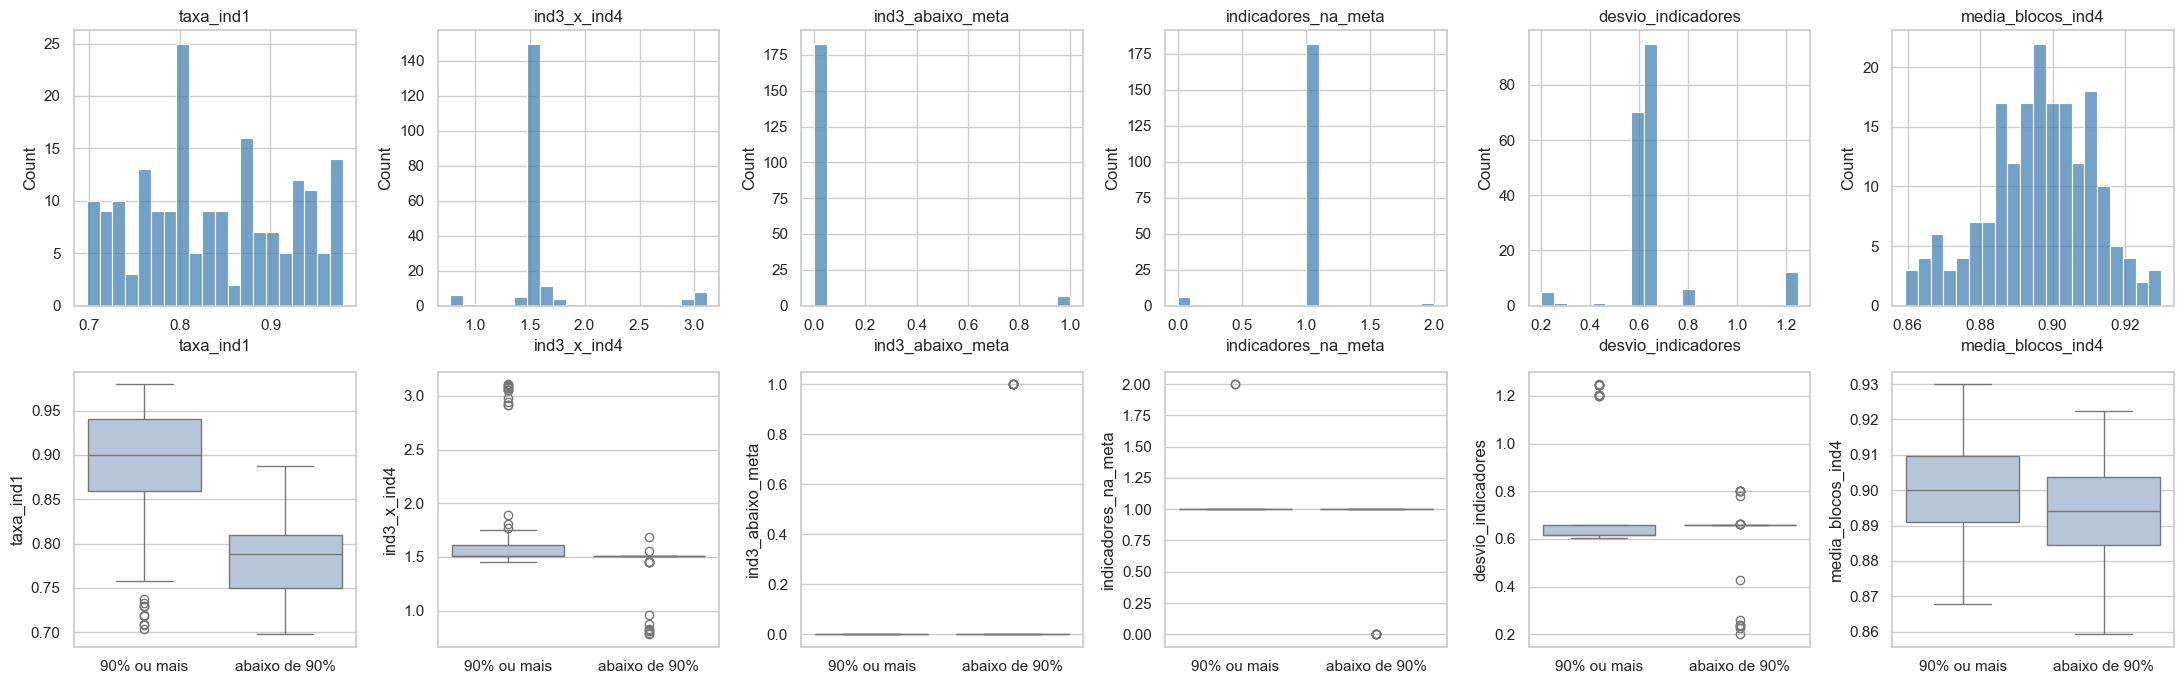

assimetria


taxa_ind1              0.11
ind3_x_ind4            2.69
ind3_abaixo_meta       4.96
indicadores_na_meta   -2.18
desvio_indicadores     1.81
media_blocos_ind4     -0.30
dtype: float64

In [15]:
# EDA das features novas: distribuição (em cima) e separação entre as classes do caderno 3 (embaixo)
alvo_90 = (unidades['geral'] < 0.9).map({True: 'abaixo de 90%', False: '90% ou mais'})

fig, eixos = plt.subplots(2, len(novas.columns), figsize=(22, 7))
for i, coluna in enumerate(novas.columns):
    sns.histplot(novas[coluna], bins=20, ax=eixos[0, i], color='steelblue')
    eixos[0, i].set_title(coluna)
    sns.boxplot(x=alvo_90, y=novas[coluna], order=['90% ou mais', 'abaixo de 90%'], ax=eixos[1, i], color='lightsteelblue')
    eixos[1, i].set_xlabel('')
plt.tight_layout()
plt.show()

print('assimetria')
novas.skew().round(2)

In [16]:
# correlação com o resultado geral (regressão) e com a classe abaixo de 90% (classificação),
# lado a lado com as notas originais
comparacao = pd.concat([unidades[notas], novas], axis=1)
pd.DataFrame({
    'com geral': comparacao.corrwith(unidades['geral']),
    'com abaixo de 90%': comparacao.corrwith((unidades['geral'] < 0.9).astype(int)),
}).round(3).sort_values('com geral', key=abs, ascending=False)

,com geral,com abaixo de 90%
ind3_x_ind4,0.933,-0.338
ind3,0.906,-0.311
desvio_indicadores,0.818,-0.174
ind4,0.491,-0.235
indicadores_na_meta,0.408,-0.213
ind3_abaixo_meta,-0.373,0.208
ind1,0.369,-0.701
taxa_ind1,0.325,-0.629
ind2,0.265,-0.175
media_blocos_ind4,0.113,-0.255


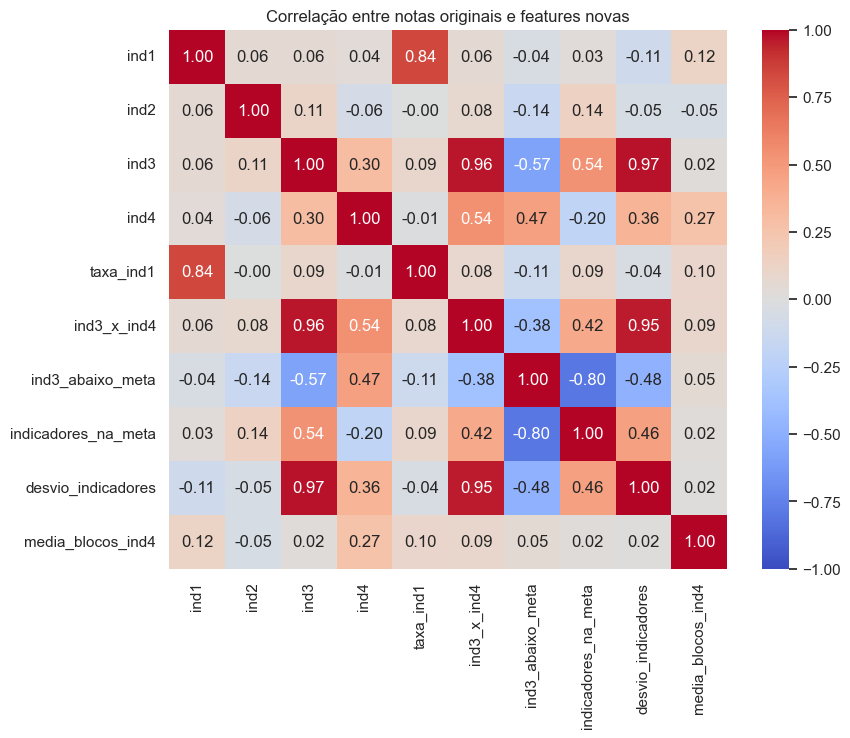

In [17]:
# redundância entre as features: correlação muito alta entre duas colunas quer dizer que uma
# repete a outra. desvio_indicadores (0,97) e ind3_x_ind4 (0,96) andam quase junto com o ind3,
# porque o ind3 é a nota que mais varia. para os modelos de árvore isso não atrapalha; num modelo
# linear ficaria só uma das três. a taxa_ind1 também repete o ind1 (0,84), mas é a versão contínua dele
plt.figure(figsize=(9, 7))
sns.heatmap(comparacao.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação entre notas originais e features novas')
plt.show()

In [18]:
# candidatas testadas e descartadas

# log do ind4: a assimetria quase não muda, porque vem de poucos valores altos (MAC e UCIS), não de cauda longa
print('assimetria do ind4:', round(unidades['ind4'].skew(), 2), '| do log(ind4):', round(np.log(unidades['ind4']).skew(), 2))

# subindicador 2.3: o ind2 é função direta dele (0 vira 0, o resto vira 0,5), então não acrescenta nada
print(pd.crosstab(origem['Desempenho — Subindicador 2.3'], unidades['ind2']))

# porte da unidade (soma dos totais avaliados, em log): não tem relação com o resultado
porte = np.log(origem[[c for c in origem.columns if c.startswith('Total avaliado')]].sum(axis=1))
print('correlação do porte com o geral:', round(porte.corr(unidades['geral']), 3))

assimetria do ind4: 1.96 | do log(ind4): 1.89
ind2                           0.0  0.5
Desempenho — Subindicador 2.3          
0.0                              5    0
0.5                              0   34
1.0                              0  151
correlação do porte com o geral: -0.001


In [19]:
# encoding das categóricas
# - familia (6 valores) e distrito (8): nominais e com poucos valores, então one-hot. o distrito vem
#   em algarismo romano, mas I < II não quer dizer nada, e label encoding inventaria essa ordem
# - tipo (17 valores): one-hot geraria 17 colunas, várias com uma ou duas unidades (CECO, USF 8);
#   label encoding guarda a informação numa coluna só e serve aos modelos de árvore, que não leem
#   o código como distância
# - o número no fim do tipo (USF 1 a 8, MAC 1 a 4) é ordinal de verdade e vira coluna numérica;
#   tipo sem número (CAPS, UBT, UCIS, CECO) fica com 0
from sklearn.preprocessing import LabelEncoder

codificador_tipo = LabelEncoder()
codificada = pd.concat([unidades, novas], axis=1)
codificada['tipo_codigo'] = codificador_tipo.fit_transform(codificada['tipo'])
codificada['nivel_tipo'] = codificada['tipo'].str.extract(r'\s(\d+)$')[0].fillna(0).astype(int)
codificada = pd.get_dummies(codificada, columns=['familia', 'distrito'], dtype=int)

print(dict(zip(codificador_tipo.classes_, range(len(codificador_tipo.classes_)))))
print(codificada.shape)
codificada.head()

{'CAPS II ou III': 0, 'CAPS III 24h': 1, 'CECO': 2, 'MAC 1': 3, 'MAC 2': 4, 'MAC 3': 5, 'MAC 4': 6, 'UBT': 7, 'UBT MISTA': 8, 'UCIS': 9, 'USF 1': 10, 'USF 2': 11, 'USF 3': 12, 'USF 4': 13, 'USF 5': 14, 'USF 6': 15, 'USF 8': 16}
(190, 28)


,tipo,ind1,ind2,ind3,ind4,geral,taxa_ind1,ind3_x_ind4,ind3_abaixo_meta,indicadores_na_meta,...,familia_UCIS,familia_USF,distrito_I,distrito_II,distrito_III,distrito_IV,distrito_V,distrito_VI,distrito_VII,distrito_VIII
0,CAPS II ou III,0.50,0.5,1.89,0.85000,0.9175,0.732673,1.606500,0,1,...,0,0,0,0,0,0,1,0,0,0
1,CAPS II ou III,0.75,0.5,1.89,0.87625,0.9779,0.970000,1.656112,0,1,...,0,0,0,0,0,0,0,1,0,0
2,CAPS II ou III,0.50,0.5,1.89,0.90150,0.9381,0.779456,1.703835,0,1,...,0,0,0,0,0,1,0,0,0,0
3,CAPS II ou III,0.75,0.5,1.89,0.87375,0.9769,0.907317,1.651388,0,1,...,0,0,0,1,0,0,0,0,0,0
4,CAPS II ou III,0.75,0.5,1.89,0.88975,0.9834,0.878543,1.681628,0,1,...,0,0,0,0,1,0,0,0,0,0


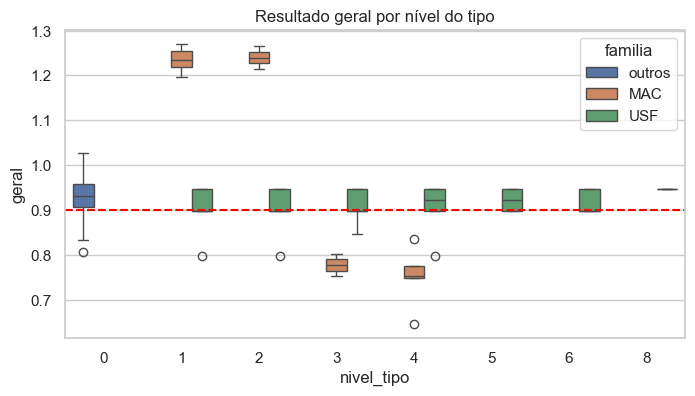

In [20]:
# o nível do tipo separa bem as MAC: 1 e 2 ficam acima de 1, 3 e 4 abaixo de 90%
plt.figure(figsize=(8, 4))
sns.boxplot(data=codificada, x='nivel_tipo', y='geral', hue=unidades['familia'].where(unidades['familia'].isin(['USF', 'MAC']), 'outros'))
plt.axhline(0.9, color='red', linestyle='--')
plt.title('Resultado geral por nível do tipo')
plt.show()

In [21]:
# padronização. os modelos de árvore dos cadernos 3 e 4 não dependem de escala, então a base salva
# fica na escala original. o K-Means do caderno 5 usa distância e precisa de média 0 e desvio 1;
# o StandardScaler é ajustado lá, sobre os dados usados, e num modelo supervisionado seria ajustado
# só no treino, para a média do teste não vazar. aqui fica o efeito nas colunas contínuas
from sklearn.preprocessing import StandardScaler

continuas = notas + ['taxa_ind1', 'ind3_x_ind4', 'desvio_indicadores', 'media_blocos_ind4']
padronizada = pd.DataFrame(StandardScaler().fit_transform(codificada[continuas]), columns=continuas)
pd.concat({'original': codificada[continuas].agg(['mean', 'std']), 'padronizada': padronizada.agg(['mean', 'std'])}).round(3)

ind1   ind2   ind3   ind4  taxa_ind1  ind3_x_ind4  \
original    mean  0.600  0.487  1.929  0.827      0.838        1.602   
            std   0.138  0.080  0.363  0.057      0.082        0.399   
padronizada mean  0.000 -0.000  0.000 -0.000      0.000       -0.000   
            std   1.003  1.003  1.003  1.003      1.003        1.003   

                  desvio_indicadores  media_blocos_ind4  
original    mean               0.669              0.896  
            std                0.166              0.015  
padronizada mean               0.000              0.000  
            std                1.003              1.003

In [22]:
# unidades.csv continua igual, porque é o que os cadernos 3 a 5 leem; a base com as features novas
# e as categóricas codificadas sai ao lado
codificada.to_csv('../saidas/unidades_features.csv', index=False)
print(codificada.shape)

(190, 28)
